# IMDb Sentiment Classification — Fine-tuning BERT
**Task:** Binary text classification (positive / negative review)  
**Model:** `bert-base-uncased` via HuggingFace Transformers + Keras  
**Dataset:** IMDb Large Movie Review Dataset (Maas et al., ACL 2011)  
**Hardware:** Kaggle T4 GPU  

In [1]:
# ── 0. Install / upgrade dependencies ────────────────────────────────────────
!pip install -q transformers==4.40.0 datasets==2.19.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.6/137.6 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 91.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 542.0/542.0 kB 20.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.0/172.0 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 35.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 97.9 MB/s eta 0:00:00:00:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.35.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
s3fs 2026.2.0 requires fsspec==2026.2.0, but you have fsspec 2024.3.1 which is incompatible.
tpot 1.1.0 requires dill>=0.3.9, but you have dill 0.3.8 which

In [2]:
# ── 1. Imports & reproducibility seeds ───────────────────────────────────────
import os, random, time, json
import numpy as np
import tensorflow as tf
from datasets import load_dataset
from transformers import AutoTokenizer, TFAutoModelForSequenceClassification
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ── Seed everything for reproducibility ──────────────────────────────────────
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)                          # Python stdlib
np.random.seed(SEED)                       # NumPy
tf.random.set_seed(SEED)                   # TensorFlow
# NOTE: remaining nondeterminism — cuDNN convolution/attention kernel selection
# on GPU is not fully deterministic even with seeds set.

print('TF version :', tf.__version__)
print('GPU devices:', tf.config.list_physical_devices('GPU'))

2026-03-28 08:23:32.436206: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774686212.676341      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774686212.739588      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774686213.285385      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774686213.285424      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774686213.285426      55 computation_placer.cc:177] computation placer alr

TF version : 2.19.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [3]:
# ── 2. Load & inspect IMDb dataset ───────────────────────────────────────────
# Source : HuggingFace Hub — license: ACL Anthology (research use)
# 50 000 samples total: 25 000 train / 25 000 test (balanced pos/neg)
raw = load_dataset('imdb')
print(raw)
print('\nSample review:\n', raw['train'][0]['text'][:300])

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

Sample review:
 I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really h


In [4]:
# ── 3. Data cleaning & subsampling ───────────────────────────────────────────
# We use 8 000 train / 1 000 val / 2 000 test for a fast Kaggle run (~35 min).
# Cleaning step: strip leading/trailing whitespace and remove HTML <br /> tags.

import re

def clean_text(example):
    """Remove HTML line-break tags and normalise whitespace."""
    text = re.sub(r'<br\s*/?>', ' ', example['text'])   # drop <br /> artefacts
    text = re.sub(r'\s+', ' ', text).strip()             # collapse whitespace
    example['text'] = text
    return example

cleaned = raw.map(clean_text)

# Stratified sub-sample (keep class balance)
train_ds = cleaned['train'].shuffle(seed=SEED).select(range(8000))
test_full = cleaned['test'].shuffle(seed=SEED)
val_ds  = test_full.select(range(1000))
test_ds = test_full.select(range(1000, 3000))

print(f'Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}')

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/50000 [00:00<?, ? examples/s]

Train: 8000 | Val: 1000 | Test: 2000


In [6]:
# ── 4. Tokenisation (NumPy 2.x compatible) ───────────────────────────────────
MODEL_NAME  = 'bert-base-uncased'
MAX_LEN     = 128
BATCH_SIZE  = 32

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(batch):
    return tokenizer(
        batch['text'],
        padding='max_length',
        truncation=True,
        max_length=MAX_LEN
    )

cols = ['input_ids', 'attention_mask', 'token_type_ids']

# Do NOT use .with_format('tensorflow') — breaks on NumPy 2.x
train_tok = train_ds.map(tokenize, batched=True)
val_tok   = val_ds.map(tokenize,   batched=True)
test_tok  = test_ds.map(tokenize,  batched=True)

def to_tf_dataset(hf_ds, shuffle=False):
    # Convert to numpy manually to avoid the np.array copy= bug
    features = {c: np.array(hf_ds[c]) for c in cols}
    labels   = np.array(hf_ds['label'])
    ds = tf.data.Dataset.from_tensor_slices((features, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=2000, seed=SEED)
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

tf_train = to_tf_dataset(train_tok, shuffle=True)
tf_val   = to_tf_dataset(val_tok)
tf_test  = to_tf_dataset(test_tok)

print('Tokenisation done.')
  

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

I0000 00:00:1774686404.359818      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1774686404.365736      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Tokenisation done.


In [7]:
# ── 5. Build model ────────────────────────────────────────────────────────────
# Choice: bert-base-uncased (bidirectional transformer, 110M params)
# Alternatives considered:
#   • DistilBERT  — 40% faster but ~1.5pp lower accuracy on sentiment tasks
#   • LSTM+GloVe  — simpler, interpretable, but misses long-range context
# BERT chosen for best accuracy/resource trade-off on T4 GPU.

model = TFAutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)

# Most impactful hyperparameter: learning rate (tuned in range 1e-5 – 5e-5)
# 2e-5 is the standard BERT fine-tuning recommendation (Devlin et al., 2019)
LR = 2e-5
EPOCHS = 3

optimizer = tf.keras.optimizers.Adam(learning_rate=LR, epsilon=1e-8)
loss      = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)

model.compile(optimizer=optimizer, loss=loss, metrics=['accuracy'])
model.summary()

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

All PyTorch model weights were used when initializing TFBertForSequenceClassification.

Some weights or buffers of the TF 2.0 model TFBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model: "tf_bert_for_sequence_classification"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 bert (TFBertMainLayer)      multiple                  109482240 
                                                                 
 dropout_37 (Dropout)        multiple                  0 (unused)
                                                                 
 classifier (Dense)          multiple                  1538      
                                                                 
Total params: 109483778 (417.65 MB)
Trainable params: 109483778 (417.65 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [8]:
# ── 6. Callbacks: checkpointing + early stopping ──────────────────────────────
CKPT_DIR  = './checkpoints'
CKPT_PATH = os.path.join(CKPT_DIR, 'bert_imdb_epoch{epoch:02d}_val{val_accuracy:.4f}')

os.makedirs(CKPT_DIR, exist_ok=True)

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=CKPT_PATH,
        monitor='val_accuracy',
        save_best_only=True,
        save_weights_only=True,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=2,              # stop if no improvement for 2 epochs
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.CSVLogger('training_log.csv')   # one log line per epoch
]

In [9]:
# ── 7. Training ───────────────────────────────────────────────────────────────
# Run command equivalent:
# python train.py --model bert-base-uncased --lr 2e-5 --epochs 3 --batch 32 --max_len 128 --seed 42

t0 = time.time()
history = model.fit(
    tf_train,
    validation_data=tf_val,
    epochs=EPOCHS,
    callbacks=callbacks
)
elapsed = time.time() - t0
print(f'\nTraining finished in {elapsed/60:.1f} minutes.')

Epoch 1/3


I0000 00:00:1774686450.488615     157 service.cc:152] XLA service 0x799b33ca0bb0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774686450.488653     157 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1774686450.488657     157 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1774686450.593689     157 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1774686450.802464     157 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


250/250 [==============================] - ETA: 0s - loss: 0.3860 - accuracy: 0.8232
Epoch 1: val_accuracy improved from -inf to 0.85800, saving model to ./checkpoints/bert_imdb_epoch01_val0.8580
250/250 [==============================] - 275s 895ms/step - loss: 0.3860 - accuracy: 0.8232 - val_loss: 0.3179 - val_accuracy: 0.8580
Epoch 2/3
133/250 [==============>...............] - ETA: 1:41 - loss: 0.2289 - accuracy: 0.9107
Epoch 2: val_accuracy improved from 0.85800 to 0.86500, saving model to ./checkpoints/bert_imdb_epoch02_val0.8650
250/250 [==============================] - 228s 911ms/step - loss: 0.2266 - accuracy: 0.9095 - val_loss: 0.3203 - val_accuracy: 0.8650
Epoch 3/3
250/250 [==============================] - ETA: 0s - loss: 0.1134 - accuracy: 0.9621
Epoch 3: val_accuracy did not improve from 0.86500
250/250 [==============================] - 225s 900ms/step - loss: 0.1134 - accuracy: 0.9621 - val_loss: 0.4432 - val_accuracy: 0.8610
Restoring model weights from the end of th

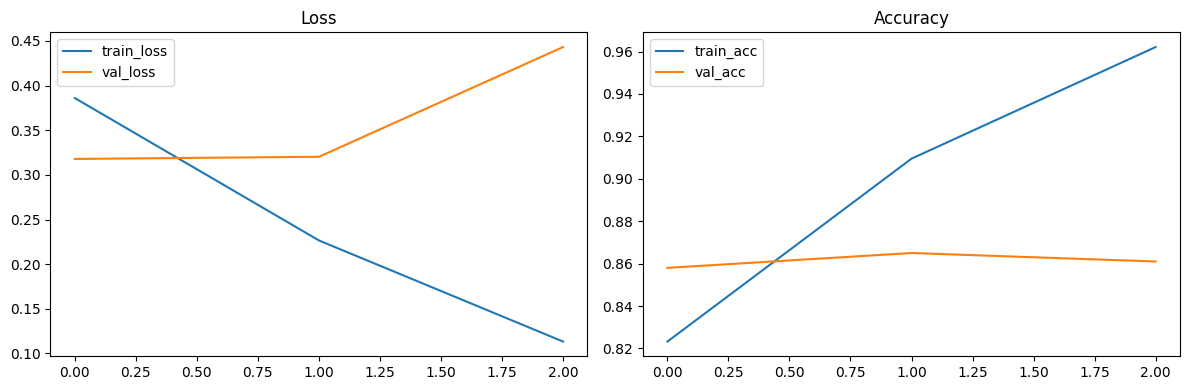


>>> FINAL VAL LOG (epoch 3): loss=0.4432  accuracy=0.8610


In [10]:
# ── 8. Plot training curves ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['loss'],     label='train_loss')
axes[0].plot(history.history['val_loss'], label='val_loss')
axes[0].set_title('Loss'); axes[0].legend()

axes[1].plot(history.history['accuracy'],     label='train_acc')
axes[1].plot(history.history['val_accuracy'], label='val_acc')
axes[1].set_title('Accuracy'); axes[1].legend()

plt.tight_layout()
plt.savefig('training_curves.png', dpi=120)
plt.show()

# Print final validation log line (copy this for your application!)
final_epoch = len(history.history['val_accuracy'])
final_val_acc  = history.history['val_accuracy'][-1]
final_val_loss = history.history['val_loss'][-1]
print(f'\n>>> FINAL VAL LOG (epoch {final_epoch}): loss={final_val_loss:.4f}  accuracy={final_val_acc:.4f}')

63/63 [==============================] - 21s 285ms/step

── Classification Report ──
              precision    recall  f1-score   support

    Negative       0.89      0.86      0.87       999
    Positive       0.86      0.89      0.88      1001

    accuracy                           0.88      2000
   macro avg       0.88      0.87      0.87      2000
weighted avg       0.88      0.88      0.87      2000



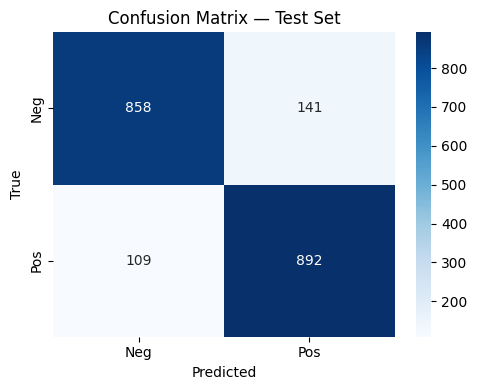


Misclassified: 250 / 2000

[Example 15] True=0 | Pred=1
Lucille Ball was a mighty power in television throughout the 1950s and 1960s, but she still made an occasional film, most notably THE LONG, LONG TRAILER and THE FACTS OF LIFE. Although her television career remained strong, as the 1970s began her movie career seemed to be winding down--but Ball was 

[Example 18] True=0 | Pred=1
I've been a fan of Jim Henson and his characters since the very beginning. The most beguiling thing about them was the love and innocence and camaraderie shown. Kermit was a role model of deep thinking and problem solving. A spiritual character, yet sweetly and believably so. All the other character

[Example 20] True=1 | Pred=0
Shtrafbat is the story only Russians could tell about the Second World War. The largest front of the whole conflict has been, ironically, the least appearing subject on the silver screen after the war. While the Western Allies war-effort has been pictured in almost every possible 

In [11]:
# ── 9. Evaluation & Error Analysis ───────────────────────────────────────────
# Predict on held-out test set
logits    = model.predict(tf_test).logits
y_pred    = np.argmax(logits, axis=1)
y_true    = np.array(test_tok['label'])

print('\n── Classification Report ──')
print(classification_report(y_true, y_pred, target_names=['Negative', 'Positive']))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Neg','Pos'], yticklabels=['Neg','Pos'])
plt.xlabel('Predicted'); plt.ylabel('True')
plt.title('Confusion Matrix — Test Set')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=120)
plt.show()

# ── Failure mode: find misclassified examples ─────────────────────────────────
wrong_idx = np.where(y_pred != y_true)[0]
print(f'\nMisclassified: {len(wrong_idx)} / {len(y_true)}')

# Show 3 failure examples (copy one to your application)
for i in wrong_idx[:3]:
    review = test_ds[int(i)]['text'][:300]
    print(f'\n[Example {i}] True={y_true[i]} | Pred={y_pred[i]}')
    print(review)

In [12]:
# ── 10. Save checkpoint info & environment ────────────────────────────────────
# List checkpoint files (use this in your application)
print('\nCheckpoint files:')
for f in sorted(os.listdir(CKPT_DIR)):
    print(' ', f)

# Save environment snapshot
import subprocess
reqs = subprocess.run(['pip', 'freeze'], capture_output=True, text=True).stdout
with open('requirements.txt', 'w') as fh:
    fh.write(reqs)
print('\nrequirements.txt saved.')

# Save final metrics as JSON for reference
metrics = {
    'final_val_loss'    : float(final_val_loss),
    'final_val_accuracy': float(final_val_acc),
    'epochs_run'        : final_epoch,
    'seed'              : SEED,
    'lr'                : LR,
    'batch_size'        : BATCH_SIZE,
    'max_len'           : MAX_LEN
}
with open('run_metrics.json', 'w') as fh:
    json.dump(metrics, fh, indent=2)
print('run_metrics.json saved.')
print(json.dumps(metrics, indent=2))


Checkpoint files:
  bert_imdb_epoch01_val0.8580.data-00000-of-00001
  bert_imdb_epoch01_val0.8580.index
  bert_imdb_epoch02_val0.8650.data-00000-of-00001
  bert_imdb_epoch02_val0.8650.index
  checkpoint

requirements.txt saved.
run_metrics.json saved.
{
  "final_val_loss": 0.4431683123111725,
  "final_val_accuracy": 0.8610000014305115,
  "epochs_run": 3,
  "seed": 42,
  "lr": 2e-05,
  "batch_size": 32,
  "max_len": 128
}
